### Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

values: This streams the full state of the graph after each node is called.

updates: This streams updates to the state of the graph after each node is called.

In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"

In [5]:
llm=ChatGroq(model="qwen/qwen3-32b")

### We will start with creating nodes

In [6]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

In [7]:
graph=StateGraph(State)

#node
graph.add_node("Superbot",superbot)

#edges
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder=graph.compile(checkpointer=memory)

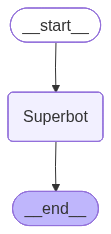

In [9]:
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
config={"configurable":{"thread_id": "1"}}

graph_builder.invoke({"messages":"Hi! My name is Bhanu, and i like cricket"}, config=config)

{'messages': [HumanMessage(content='Hi! My name is Bhanu, and i like cricket', additional_kwargs={}, response_metadata={}, id='71c2d8b1-30a9-485a-b28e-72d8cb811f43'),
  AIMessage(content='<think>\nOkay, the user introduced themselves as Bhanu and mentioned they like cricket. I should respond in a friendly and welcoming manner, acknowledging their introduction and showing interest in their interest in cricket. I can ask a follow-up question to encourage further conversation about their favorite teams, players, or memorable matches. I should keep the tone positive and engaging. Let me make sure to use proper punctuation and a friendly emoji to keep the atmosphere light. Also, I need to check for any grammar issues to ensure clarity.\n\nLet me start with a greeting that matches their enthusiasm. Maybe something like "Hi Bhanu! 👏 Nice to meet you!" Then express excitement about their cricket interest. Next, ask a question to delve deeper into their preferences. Maybe inquire about their fa

### Streaming the responses with stream method

With "updates", you get the latest state of hte graph

With "values", you get the all the past messages of the gtaph displayed

In [12]:
config={"configurable":{"thread_id": "2"}}

for chunk in graph_builder.stream({"messages":"Hi! My name is Bhanu, and i like cricket"}, config=config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced themselves as Bhanu and mentioned they like cricket. So I should start by greeting them back and acknowledge their interest in cricket. Maybe ask them which team they support or if they play the game. Also, I can offer to discuss cricket topics like recent matches, players, or strategies. Keep the response friendly and open-ended to encourage further conversation. Let me make sure the tone is positive and engaging.\n</think>\n\nHello Bhanu! Nice to meet you. 🏏 I'd love to hear more about your passion for cricket. Do you have a favorite team or player? Or do you enjoy playing the game yourself? We can discuss anything from recent matches to cricket strategies - just let me know what interests you most!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 154, 'prompt_tokens': 21, 'total_tokens': 175, 'completion_time': 0.346618644, 'completion_tokens_details': None, 'prompt_time':

In [13]:
for chunk in graph_builder.stream({"messages":"Hi! My name is Bhanu, and i like cricket"}, config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi! My name is Bhanu, and i like cricket', additional_kwargs={}, response_metadata={}, id='d0c68715-0984-4827-919c-c8fd516cf12a'), AIMessage(content="<think>\nOkay, the user introduced themselves as Bhanu and mentioned they like cricket. So I should start by greeting them back and acknowledge their interest in cricket. Maybe ask them which team they support or if they play the game. Also, I can offer to discuss cricket topics like recent matches, players, or strategies. Keep the response friendly and open-ended to encourage further conversation. Let me make sure the tone is positive and engaging.\n</think>\n\nHello Bhanu! Nice to meet you. 🏏 I'd love to hear more about your passion for cricket. Do you have a favorite team or player? Or do you enjoy playing the game yourself? We can discuss anything from recent matches to cricket strategies - just let me know what interests you most!", additional_kwargs={}, response_metadata={'token_usage': {'completi

In [14]:
for chunk in graph_builder.stream({"messages":"I also like kabaddi"}, config=config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="<think>\nOkay, the user mentioned they like both cricket and kabaddi. I should acknowledge both sports to show I'm listening. Let me start by expressing enthusiasm for their interest in kabaddi. Maybe ask if they follow any particular teams or players in kabaddi. Also, since they play or watch cricket, maybe they're into other sports too. I should keep the conversation open-ended so they can share more. Need to make sure the response is friendly and encouraging. Avoid jargon to keep it accessible. Check for any cultural nuances, like popular kabaddi leagues in India. Maybe mention Pro Kabaddi League as an example. Keep the tone positive and engaging.\n</think>\n\nThat’s awesome, Bhanu! 🏐 Kabaddi is such a high-energy, strategic sport—love that it combines strength, agility, and teamwork. Do you follow the **Pro Kabaddi League** or any specific teams/players? I’d love to hear what draws you to it! And if you play either sport, do you enjoy t

In [16]:
for chunk in graph_builder.stream({"messages":"I love sports!"}, config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi! My name is Bhanu, and i like cricket', additional_kwargs={}, response_metadata={}, id='d0c68715-0984-4827-919c-c8fd516cf12a'), AIMessage(content="<think>\nOkay, the user introduced themselves as Bhanu and mentioned they like cricket. So I should start by greeting them back and acknowledge their interest in cricket. Maybe ask them which team they support or if they play the game. Also, I can offer to discuss cricket topics like recent matches, players, or strategies. Keep the response friendly and open-ended to encourage further conversation. Let me make sure the tone is positive and engaging.\n</think>\n\nHello Bhanu! Nice to meet you. 🏏 I'd love to hear more about your passion for cricket. Do you have a favorite team or player? Or do you enjoy playing the game yourself? We can discuss anything from recent matches to cricket strategies - just let me know what interests you most!", additional_kwargs={}, response_metadata={'token_usage': {'completi

### Streaming the responses with astream method

Streaming tokens We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the tokens as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

1. event: This is the type of event that is being emitted.

2. name: This is the name of event.

3. data: This is the data associated with the event.

4. metadata: Containslanggraph_node, the node emitting the event.

In [17]:
config={"configurable":{"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi, my name is krish and I like to play cricket"]},config=config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi, my name is krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e5ee0-82af-7531-b7cc-c91be6bd8f09', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, my name is krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='b8f51b54-c4da-4a95-8f1b-222fe838abed')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019e5ee0-82b6-77b1-8e4f-bc8ac38422dc', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:bf4ddfe9-73f6-6306-72ab-6d6747536c84'}, 'parent_ids': ['019e5ee0-82af-7531-b7cc-c91be6bd8f09']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages